# EDA forte — comportamento sequencial, temporal e adequação para KT / LPKT

Este notebook foi criado para validar, com dados reais do projeto, pontos críticos para Knowledge Tracing:

1. **Qualidade e cobertura dos dados**
2. **Comprimento das sequências por aluno**
3. **Consistência temporal e formação de sessões**
4. **Fragmentação de estudo / troca de skills**
5. **Intensidade de repetição por skill**
6. **Outliers e zeros em `time_response`**
7. **Adequação dos dados às hipóteses do LPKT**
8. **Implicações para DKT, LPKT e próximos modelos (ex.: DKVMN)**

> Objetivo: responder, com evidência, se o comportamento real dos alunos parece
suficientemente consistente para que modelos processo-temporais como o **LPKT**
sejam plenamente adequados no cenário atual.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

RAW_ANSWERS_PATH = PROJECT_ROOT / "data" / "raw" / "answers.json"
PREPARED_PATH = PROJECT_ROOT / "data" / "processed" / "dataset" / "answers_prepared.csv"
SEQUENCES_PATH = PROJECT_ROOT / "data" / "processed" / "sequences" / "user_sequences.json"
H2_MAP_PATH = PROJECT_ROOT / "data" / "processed" / "mappings" / "skill_to_h2.json"
H3_MAP_PATH = PROJECT_ROOT / "data" / "processed" / "mappings" / "skill_to_h3.json"

assert PREPARED_PATH.exists(), f"Arquivo não encontrado: {PREPARED_PATH}"
assert SEQUENCES_PATH.exists(), f"Arquivo não encontrado: {SEQUENCES_PATH}"

answers = pd.read_csv(PREPARED_PATH)
with open(SEQUENCES_PATH, "r", encoding="utf-8") as f:
    sequences = json.load(f)

skill_to_h2 = {}
skill_to_h3 = {}
if H2_MAP_PATH.exists():
    with open(H2_MAP_PATH, "r", encoding="utf-8") as f:
        skill_to_h2 = json.load(f)
if H3_MAP_PATH.exists():
    with open(H3_MAP_PATH, "r", encoding="utf-8") as f:
        skill_to_h3 = json.load(f)

answers["timestamp_dt"] = pd.to_datetime(answers["timestamp"], unit="ms", errors="coerce")
answers.head()


,user_id,question_id,skill_id,correct,timestamp,time_response,delta_t,timestamp_dt
0,0015ac16-1de0-52d5-955f-45544827a9e2,291a427c-9646-40d8-994c-f1bffe2b3870,779463fc-0c95-4da8-8244-19668aded311,1,1718131264252,25806,0,2024-06-11 18:41:04.252
1,0015ac16-1de0-52d5-955f-45544827a9e2,67856b5d-b0ad-443f-b099-0dfe426d5c2b,779463fc-0c95-4da8-8244-19668aded311,0,1718131319746,47033,55494,2024-06-11 18:41:59.746
2,0015ac16-1de0-52d5-955f-45544827a9e2,c1289418-bdb6-4150-a61b-7ddce0e63555,779463fc-0c95-4da8-8244-19668aded311,1,1718131382712,22553,62966,2024-06-11 18:43:02.712
3,0015ac16-1de0-52d5-955f-45544827a9e2,eb54477f-878a-4ba9-a8f1-a22be1086c05,eb40bbbd-3880-4421-ab2f-426f25ba1eb3,1,1718131434953,48527,52241,2024-06-11 18:43:54.953
4,0015ac16-1de0-52d5-955f-45544827a9e2,ecf48069-ecbc-4049-9bb7-b6652ad79ed8,779463fc-0c95-4da8-8244-19668aded311,1,1718131464241,23678,29288,2024-06-11 18:44:24.241


## 1. Visão geral do dataset preparado

Primeiro validamos volume, cobertura e integridade básica. Esta etapa responde:

- quantas interações válidas existem;
- quantos alunos, questões e skills estão presentes;
- se ainda há valores faltantes ou duplicidade;
- qual a taxa global de acerto.


In [2]:
overview = pd.Series({
    "n_rows": len(answers),
    "n_unique_users": answers["user_id"].nunique(),
    "n_unique_questions": answers["question_id"].nunique(),
    "n_unique_skills": answers["skill_id"].nunique() if "skill_id" in answers.columns else np.nan,
    "correct_rate": float(answers["correct"].mean()),
    "time_response_zero_rate": float((answers["time_response"] == 0).mean()),
    "time_response_missing_rate": float(answers["time_response"].isna().mean()),
    "duplicated_rows": int(answers.duplicated().sum()),
    "null_user_id": int(answers["user_id"].isna().sum()),
    "null_question_id": int(answers["question_id"].isna().sum()),
    "null_skill_id": int(answers["skill_id"].isna().sum()) if "skill_id" in answers.columns else np.nan,
    "null_correct": int(answers["correct"].isna().sum()),
    "null_timestamp": int(answers["timestamp"].isna().sum()),
})
overview.to_frame("value")


,value
n_rows,1.646514e+06
n_unique_users,1.706000e+03
n_unique_questions,1.200300e+05
n_unique_skills,4.720000e+02
correct_rate,6.879747e-01
time_response_zero_rate,1.840920e-02
time_response_missing_rate,0.000000e+00
duplicated_rows,0.000000e+00
null_user_id,0.000000e+00
null_question_id,0.000000e+00


### Leitura esperada

- Se `duplicated_rows`, `null_*` e valores inválidos forem baixos, o pipeline está saudável.
- `correct_rate` alto ajuda a explicar por que **accuracy sozinha** é enganosa.
- `time_response_zero_rate` alto sugere que a feature temporal pode conter ruído relevante para LPKT.


## 2. Distribuição de interações por aluno

Esta é uma das análises mais importantes para KT. Modelos sequenciais dependem de
históricos por usuário longos o suficiente para aprender padrões.

Perguntas:
- quantos alunos têm poucas interações?
- a média esconde uma cauda longa?
- temos usuários suficientes com histórico robusto para LPKT?


In [3]:
user_stats = (
    answers.groupby("user_id")
    .agg(
        n_interactions=("question_id", "size"),
        n_unique_questions=("question_id", "nunique"),
        n_unique_skills=("skill_id", "nunique"),
        correct_rate=("correct", "mean"),
        first_ts=("timestamp_dt", "min"),
        last_ts=("timestamp_dt", "max"),
    )
    .reset_index()
)
user_stats["timespan_hours"] = (
    (user_stats["last_ts"] - user_stats["first_ts"]).dt.total_seconds() / 3600
).fillna(0)

user_stats[["n_interactions", "n_unique_skills", "correct_rate", "timespan_hours"]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,n_interactions,n_unique_skills,correct_rate,timespan_hours
count,1706.000000,1706.000000,1706.000000,1706.000000
mean,965.131301,77.828839,0.653515,1453.582923
std,1549.663152,85.075223,0.104035,782.733636
min,2.000000,1.000000,0.000000,0.000000
10%,50.000000,6.000000,0.525993,170.399324
25%,120.000000,14.000000,0.593165,763.246139
50%,355.000000,40.000000,0.659906,1739.428021
75%,1069.250000,117.000000,0.721804,2174.059670
90%,2682.500000,209.500000,0.777525,2256.350302
95%,3942.750000,259.000000,0.810132,2278.162510


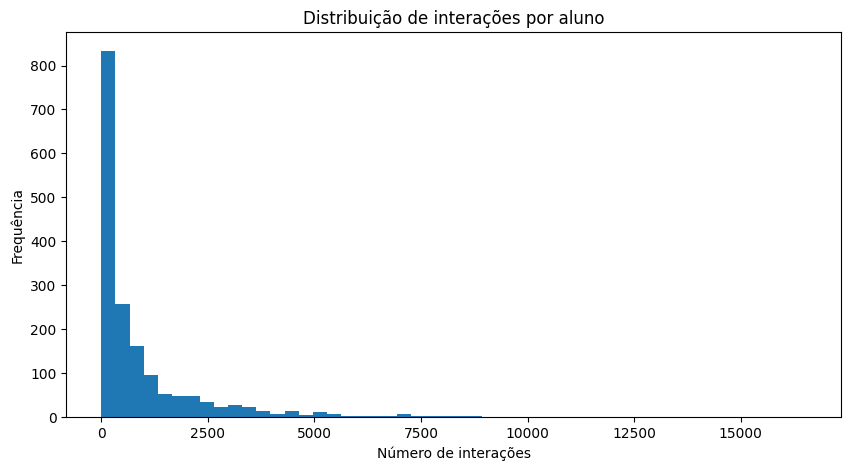

,threshold,n_users_ge_threshold,share_users_ge_threshold
0,10,1681,0.985346
1,20,1644,0.963658
2,30,1613,0.945487
3,50,1540,0.902696
4,80,1425,0.835287
5,100,1347,0.789566
6,150,1199,0.702814


In [4]:
fig = plt.figure(figsize=(10, 5))
plt.hist(user_stats["n_interactions"], bins=50)
plt.title("Distribuição de interações por aluno")
plt.xlabel("Número de interações")
plt.ylabel("Frequência")
plt.show()

thresholds = [10, 20, 30, 50, 80, 100, 150]
coverage = pd.DataFrame({
    "threshold": thresholds,
    "n_users_ge_threshold": [(user_stats["n_interactions"] >= t).sum() for t in thresholds],
    "share_users_ge_threshold": [float((user_stats["n_interactions"] >= t).mean()) for t in thresholds],
})
coverage


### Interpretação

Se a maior parte dos alunos tiver poucas interações, o KT por aluno fica mais fraco.
Isso afeta todos os modelos, mas prejudica mais abordagens que dependem de **trajetórias temporais estáveis**.


## 3. Validação das sequências já construídas

Além das linhas do dataset preparado, validamos o artefato `user_sequences.json`,
que é o insumo direto dos treinos.


In [5]:
seq_lengths = pd.Series([len(s["question_ids"]) for s in sequences], name="seq_len")
seq_df = pd.DataFrame({
    "user_id": [s["user_id"] for s in sequences],
    "seq_len": [len(s["question_ids"]) for s in sequences],
    "n_unique_skills_seq": [len(set(s["skill_ids"])) for s in sequences],
    "zero_time_ratio_seq": [
        float(np.mean(np.array(s["time_responses"]) == 0)) if len(s["time_responses"]) else np.nan
        for s in sequences
    ],
})
seq_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,seq_len,n_unique_skills_seq,zero_time_ratio_seq
count,1706.000000,1706.000000,1706.000000
mean,965.131301,77.828839,0.030419
std,1549.663152,85.075223,0.046355
min,2.000000,1.000000,0.000000
10%,50.000000,6.000000,0.000000
25%,120.000000,14.000000,0.000283
50%,355.000000,40.000000,0.012070
75%,1069.250000,117.000000,0.042656
90%,2682.500000,209.500000,0.092539
95%,3942.750000,259.000000,0.112153


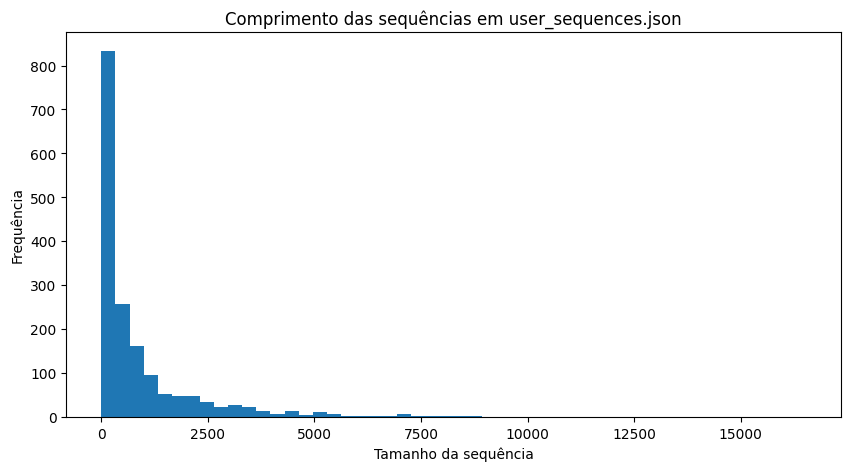

In [6]:
fig = plt.figure(figsize=(10, 5))
plt.hist(seq_df["seq_len"], bins=50)
plt.title("Comprimento das sequências em user_sequences.json")
plt.xlabel("Tamanho da sequência")
plt.ylabel("Frequência")
plt.show()


## 4. Diagnóstico temporal

Aqui verificamos se o tempo realmente carrega sinal útil ou se está contaminado por:
- zeros estruturais;
- outliers muito grandes;
- gaps que misturam múltiplas sessões em uma única sequência.

Isso é crucial para LPKT.


In [7]:
time_stats = pd.Series({
    "time_response_zero_rate": float((answers["time_response"] == 0).mean()),
    "time_response_p50_sec": float(answers["time_response"].quantile(0.50) / 1000),
    "time_response_p90_sec": float(answers["time_response"].quantile(0.90) / 1000),
    "time_response_p95_sec": float(answers["time_response"].quantile(0.95) / 1000),
    "time_response_p99_sec": float(answers["time_response"].quantile(0.99) / 1000),
    "time_response_max_sec": float(answers["time_response"].max() / 1000),
})
time_stats.to_frame("value")


,value
time_response_zero_rate,1.840920e-02
time_response_p50_sec,5.000800e+01
time_response_p90_sec,7.449844e+02
time_response_p95_sec,3.738058e+03
time_response_p99_sec,7.222014e+04
time_response_max_sec,6.757615e+06


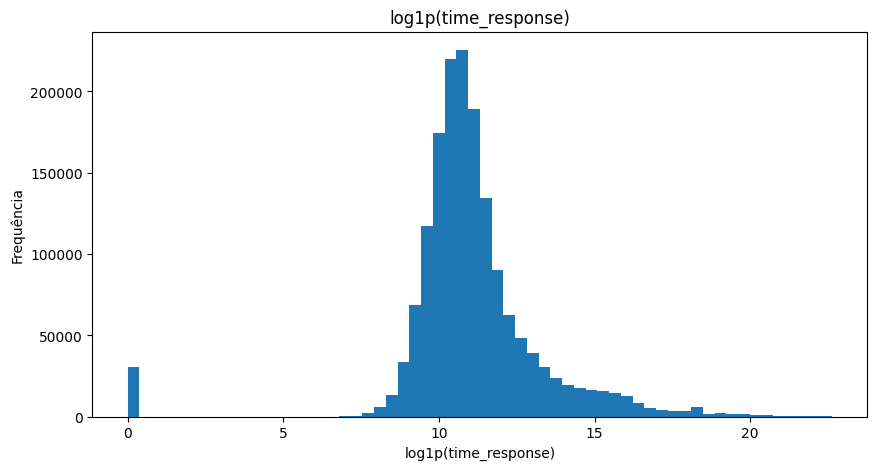

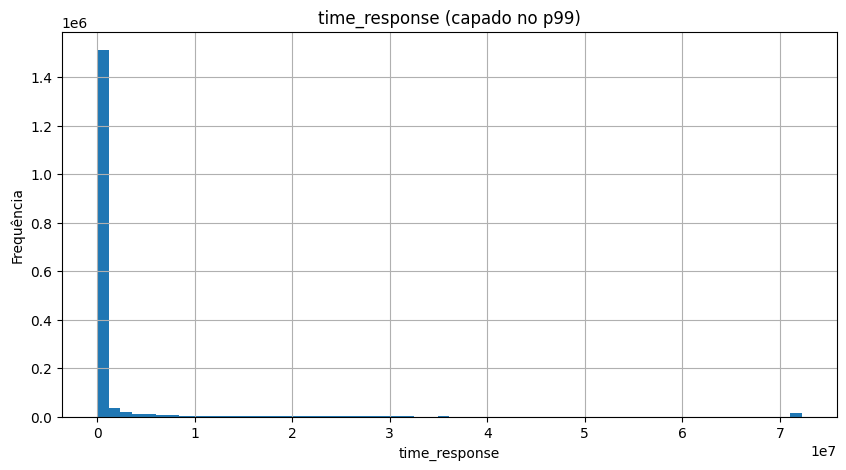

In [8]:
fig = plt.figure(figsize=(10, 5))
plt.hist(np.log1p(answers["time_response"]), bins=60)
plt.title("log1p(time_response)")
plt.xlabel("log1p(time_response)")
plt.ylabel("Frequência")
plt.show()

fig = plt.figure(figsize=(10, 5))
answers["time_response"].clip(upper=answers["time_response"].quantile(0.99)).hist(bins=60)
plt.title("time_response (capado no p99)")
plt.xlabel("time_response")
plt.ylabel("Frequência")
plt.show()


In [9]:
answers = answers.sort_values(["user_id", "timestamp"]).copy()
answers["delta_t_ms"] = answers.groupby("user_id")["timestamp"].diff().fillna(0)
answers["delta_t_min"] = answers["delta_t_ms"] / 60000

delta_stats = pd.Series({
    "delta_t_zero_rate": float((answers["delta_t_ms"] == 0).mean()),
    "delta_t_p50_min": float(answers["delta_t_min"].quantile(0.50)),
    "delta_t_p90_min": float(answers["delta_t_min"].quantile(0.90)),
    "delta_t_p95_min": float(answers["delta_t_min"].quantile(0.95)),
    "delta_t_p99_min": float(answers["delta_t_min"].quantile(0.99)),
    "delta_t_max_hours": float(answers["delta_t_min"].max() / 60),
})
delta_stats.to_frame("value")


,value
delta_t_zero_rate,0.133908
delta_t_p50_min,0.954708
delta_t_p90_min,6.578107
delta_t_p95_min,30.042867
delta_t_p99_min,1470.768661
delta_t_max_hours,2174.762207


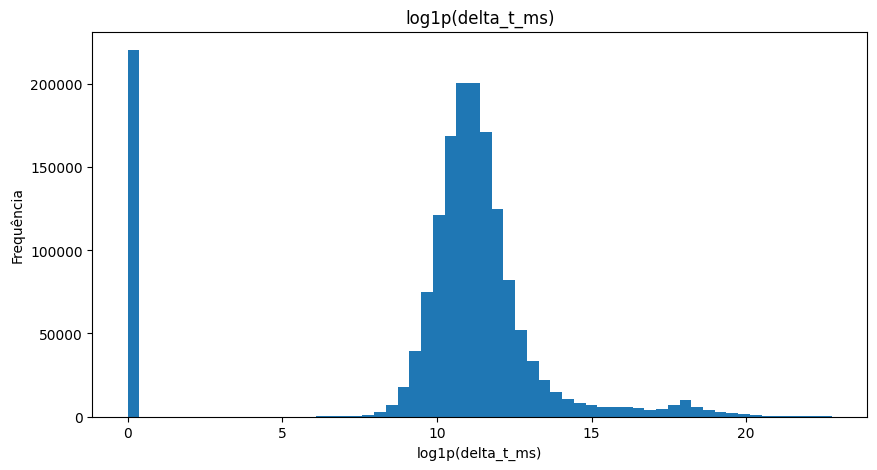

In [10]:
fig = plt.figure(figsize=(10, 5))
plt.hist(np.log1p(answers["delta_t_ms"]), bins=60)
plt.title("log1p(delta_t_ms)")
plt.xlabel("log1p(delta_t_ms)")
plt.ylabel("Frequência")
plt.show()


### Observação

Se `time_response` e `delta_t` tiverem muitos zeros e muitos outliers, a informação temporal
pode ser útil em parte dos casos, mas também pode introduzir bastante ruído.
Isso reduz a vantagem potencial do LPKT.


## 5. Formação de sessões

KT temporal costuma funcionar melhor quando a sequência representa uma trajetória coerente
de estudo. Uma forma prática de validar isso é quebrar interações em **sessões**.

Aqui usamos uma heurística simples:
- nova sessão quando `delta_t > 60 min`


In [11]:
SESSION_GAP_MIN = 60

answers["new_session_flag"] = (
    (answers["delta_t_min"] > SESSION_GAP_MIN) | (answers.groupby("user_id").cumcount() == 0)
).astype(int)

answers["session_idx"] = answers.groupby("user_id")["new_session_flag"].cumsum()

session_stats = (
    answers.groupby(["user_id", "session_idx"])
    .agg(
        n_interactions=("question_id", "size"),
        n_unique_skills=("skill_id", "nunique"),
        duration_min=("delta_t_min", "sum"),
        correct_rate=("correct", "mean"),
    )
    .reset_index()
)

session_stats.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,session_idx,n_interactions,n_unique_skills,duration_min,correct_rate
count,69638.000000,69638.000000,69638.000000,69638.000000,69638.000000
mean,48.992648,23.643901,5.110040,2136.602832,0.662991
std,48.332442,24.603900,10.499784,6226.057860,0.214624
min,1.000000,1.000000,1.000000,0.000000,0.000000
10%,5.000000,3.000000,1.000000,117.116648,0.400000
25%,13.000000,8.000000,1.000000,221.581750,0.565217
50%,33.000000,16.000000,2.000000,741.049600,0.692308
75%,70.000000,30.000000,5.000000,1480.038437,0.800000
90%,117.000000,52.000000,10.000000,4278.022570,0.900000
95%,148.000000,74.000000,16.000000,7891.881237,1.000000


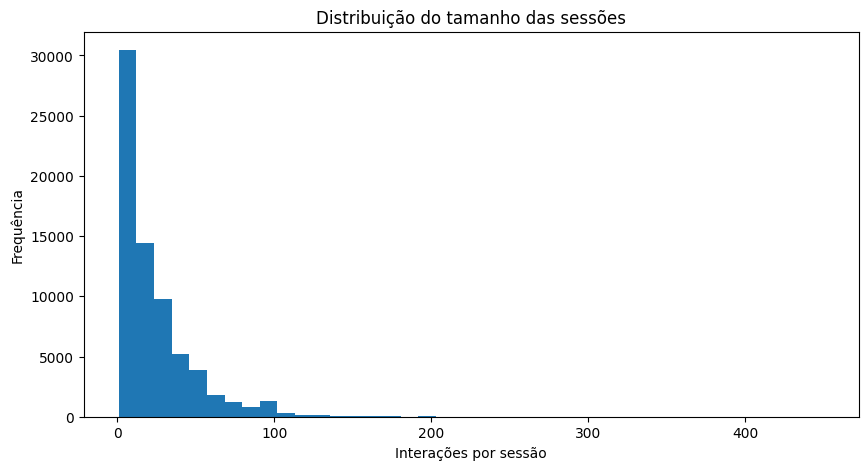

,value
n_sessions,69638.000000
mean_session_len,23.643901
median_session_len,16.000000
share_sessions_len_le_3,0.126885
share_sessions_len_ge_10,0.708837


In [12]:
fig = plt.figure(figsize=(10, 5))
plt.hist(session_stats["n_interactions"], bins=40)
plt.title("Distribuição do tamanho das sessões")
plt.xlabel("Interações por sessão")
plt.ylabel("Frequência")
plt.show()

session_summary = pd.Series({
    "n_sessions": len(session_stats),
    "mean_session_len": float(session_stats["n_interactions"].mean()),
    "median_session_len": float(session_stats["n_interactions"].median()),
    "share_sessions_len_le_3": float((session_stats["n_interactions"] <= 3).mean()),
    "share_sessions_len_ge_10": float((session_stats["n_interactions"] >= 10).mean()),
})
session_summary.to_frame("value")


### Interpretação

Se muitas sessões forem muito curtas, isso sugere que o histórico total do aluno mistura
vários fragmentos pequenos de estudo. Para LPKT, pode ser melhor treinar por sessão ou por contexto.


## 6. Fragmentação por skill e troca de assunto

Agora testamos diretamente uma hipótese central:

> o aluno pratica uma skill de forma relativamente contínua ou fica trocando de skill o tempo todo?

Se houver muita troca, o dado fica menos compatível com a hipótese de progresso contínuo do LPKT.


In [13]:
answers["prev_skill_id"] = answers.groupby("user_id")["skill_id"].shift(1)
answers["skill_switch"] = (
    (answers["prev_skill_id"].notna()) & (answers["skill_id"] != answers["prev_skill_id"])
).astype(int)

user_fragmentation = (
    answers.groupby("user_id")
    .agg(
        n_interactions=("question_id", "size"),
        n_unique_skills=("skill_id", "nunique"),
        n_skill_switches=("skill_switch", "sum"),
    )
    .reset_index()
)
user_fragmentation["skill_switch_rate"] = (
    user_fragmentation["n_skill_switches"] / (user_fragmentation["n_interactions"] - 1).clip(lower=1)
)
user_fragmentation["interactions_per_skill"] = (
    user_fragmentation["n_interactions"] / user_fragmentation["n_unique_skills"].clip(lower=1)
)
user_fragmentation.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


,n_interactions,n_unique_skills,n_skill_switches,skill_switch_rate,interactions_per_skill
count,1706.000000,1706.000000,1706.000000,1706.000000,1706.000000
mean,965.131301,77.828839,288.460141,0.292686,11.879478
std,1549.663152,85.075223,558.653465,0.231646,8.630296
min,2.000000,1.000000,0.000000,0.000000,1.000000
10%,50.000000,6.000000,6.000000,0.088608,3.448211
25%,120.000000,14.000000,23.000000,0.120970,6.336207
50%,355.000000,40.000000,89.000000,0.216819,9.903704
75%,1069.250000,117.000000,288.750000,0.390776,14.737466
90%,2682.500000,209.500000,737.500000,0.651240,22.459302
95%,3942.750000,259.000000,1228.750000,0.840196,29.571822


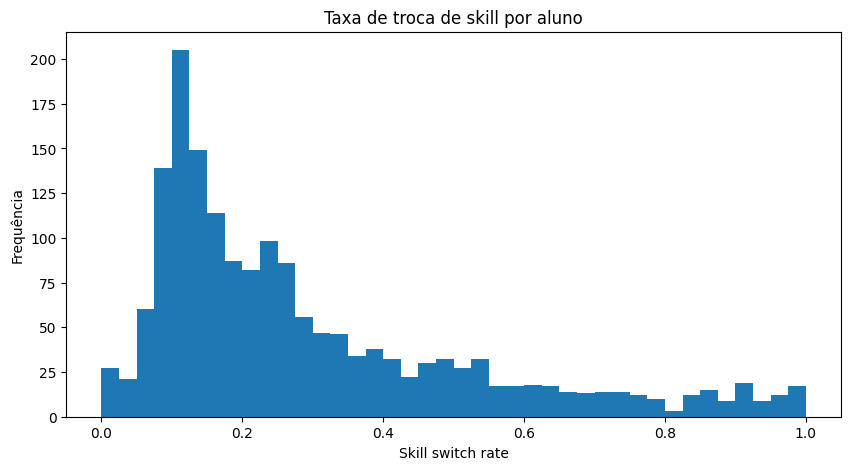

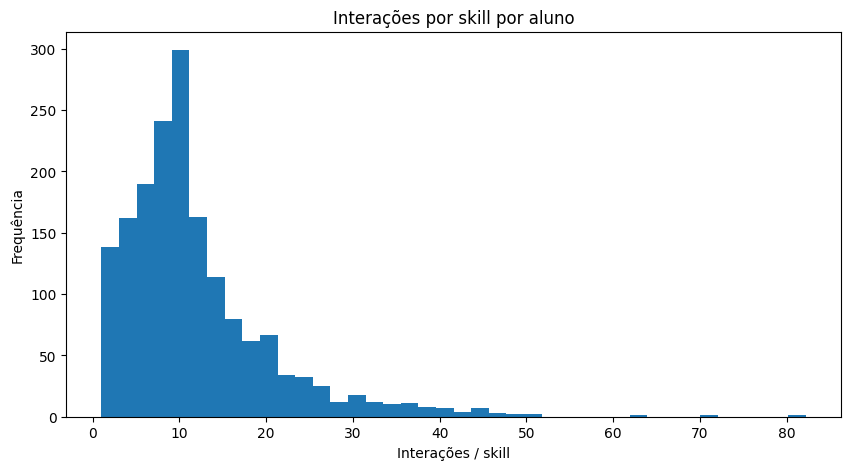

In [14]:
fig = plt.figure(figsize=(10, 5))
plt.hist(user_fragmentation["skill_switch_rate"], bins=40)
plt.title("Taxa de troca de skill por aluno")
plt.xlabel("Skill switch rate")
plt.ylabel("Frequência")
plt.show()

fig = plt.figure(figsize=(10, 5))
plt.hist(user_fragmentation["interactions_per_skill"], bins=40)
plt.title("Interações por skill por aluno")
plt.xlabel("Interações / skill")
plt.ylabel("Frequência")
plt.show()


In [15]:
runs = []
for user_id, g in answers.groupby("user_id"):
    g = g.sort_values("timestamp")
    current_skill = None
    run_len = 0
    for skill in g["skill_id"]:
        if skill != current_skill:
            if run_len > 0:
                runs.append(run_len)
            current_skill = skill
            run_len = 1
        else:
            run_len += 1
    if run_len > 0:
        runs.append(run_len)

runs = pd.Series(runs, name="run_length")
runs.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


count    495287.000000
mean          3.324363
std           4.803577
min           1.000000
10%           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
90%          10.000000
95%          10.000000
99%          20.000000
max         357.000000
Name: run_length, dtype: float64

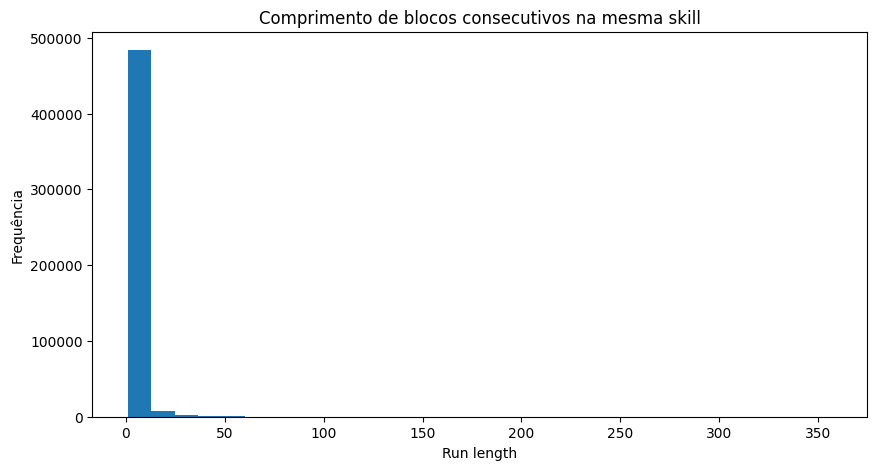

In [16]:
fig = plt.figure(figsize=(10, 5))
plt.hist(runs, bins=30)
plt.title("Comprimento de blocos consecutivos na mesma skill")
plt.xlabel("Run length")
plt.ylabel("Frequência")
plt.show()


### Interpretação

- **Skill switch rate alto** → estudo mais fragmentado
- **Interactions per skill baixo** → pouco aprofundamento por conceito
- **Runs curtos** → menor coerência conceitual local

Esse conjunto de sinais é uma das evidências mais fortes contra a hipótese de sequência pedagógica limpa.


## 7. Repetição local e prática deliberada

O LPKT tende a se beneficiar quando há repetição suficiente para modelar progresso e esquecimento.
Aqui medimos quantas vezes o mesmo aluno revisita a mesma skill.


In [17]:
user_skill_counts = (
    answers.groupby(["user_id", "skill_id"])
    .size()
    .reset_index(name="n_attempts")
)

user_skill_counts["attempt_bucket"] = pd.cut(
    user_skill_counts["n_attempts"],
    bins=[0, 1, 2, 3, 5, 10, 20, 50, np.inf],
    labels=["1", "2", "3", "4-5", "6-10", "11-20", "21-50", "50+"],
    right=True,
)

repeat_summary = pd.Series({
    "mean_attempts_per_user_skill": float(user_skill_counts["n_attempts"].mean()),
    "median_attempts_per_user_skill": float(user_skill_counts["n_attempts"].median()),
    "share_user_skills_attempted_once": float((user_skill_counts["n_attempts"] == 1).mean()),
    "share_user_skills_attempted_ge_3": float((user_skill_counts["n_attempts"] >= 3).mean()),
    "share_user_skills_attempted_ge_5": float((user_skill_counts["n_attempts"] >= 5).mean()),
})
repeat_summary.to_frame("value")


,value
mean_attempts_per_user_skill,12.400690
median_attempts_per_user_skill,8.000000
share_user_skills_attempted_once,0.230147
share_user_skills_attempted_ge_3,0.682955
share_user_skills_attempted_ge_5,0.587779


In [18]:
attempt_bucket_counts = (
    user_skill_counts["attempt_bucket"]
    .value_counts(sort=False, dropna=False)
    .rename_axis("bucket")
    .reset_index(name="count")
)
attempt_bucket_counts


,bucket,count
0,1,30558
1,2,11538
2,3,7936
3,4-5,8306
4,6-10,29668
5,11-20,22208
6,21-50,17585
7,50+,4977


### Interpretação

Se a maioria das combinações `aluno × skill` ocorrer apenas 1 vez ou 2 vezes, o modelo tem pouca oportunidade
para aprender **evolução de mastery** naquela skill específica.


## 8. Cobertura H2 / H3

Também verificamos se a hierarquia conceitual cobre bem as skills observadas.


In [19]:
skills_observed = set(answers["skill_id"].dropna().unique())
coverage_h2 = len(skills_observed & set(skill_to_h2.keys())) / max(len(skills_observed), 1)
coverage_h3 = len(skills_observed & set(skill_to_h3.keys())) / max(len(skills_observed), 1)

pd.Series({
    "observed_skills": len(skills_observed),
    "mapped_h2_skills": len(skills_observed & set(skill_to_h2.keys())),
    "mapped_h3_skills": len(skills_observed & set(skill_to_h3.keys())),
    "coverage_h2": coverage_h2,
    "coverage_h3": coverage_h3,
}).to_frame("value")


,value
observed_skills,472.000000
mapped_h2_skills,464.000000
mapped_h3_skills,464.000000
coverage_h2,0.983051
coverage_h3,0.983051


## 9. Critérios práticos de adequação ao LPKT

A seguir montamos um quadro simples de diagnóstico. Não é uma regra formal, mas um guia objetivo.


In [20]:
diagnostic = pd.DataFrame([
    {
        "criterion": "Sequências longas por aluno",
        "indicator": "mediana de interações por aluno",
        "value": float(user_stats["n_interactions"].median()),
        "interpretation": "quanto maior, melhor para KT temporal"
    },
    {
        "criterion": "Sessões com tamanho útil",
        "indicator": "mediana de interações por sessão",
        "value": float(session_stats["n_interactions"].median()),
        "interpretation": "sessões muito curtas reduzem coerência temporal"
    },
    {
        "criterion": "Baixa fragmentação",
        "indicator": "mediana da taxa de troca de skill",
        "value": float(user_fragmentation["skill_switch_rate"].median()),
        "interpretation": "valores altos sugerem estudo disperso"
    },
    {
        "criterion": "Repetição suficiente por skill",
        "indicator": "share de aluno×skill com >= 3 tentativas",
        "value": float((user_skill_counts["n_attempts"] >= 3).mean()),
        "interpretation": "quanto maior, melhor para modelar mastery"
    },
    {
        "criterion": "Tempo informativo",
        "indicator": "share de time_response == 0",
        "value": float((answers["time_response"] == 0).mean()),
        "interpretation": "muitos zeros reduzem sinal temporal"
    },
])
diagnostic


,criterion,indicator,value,interpretation
0,Sequências longas por aluno,mediana de interações por aluno,355.000000,"quanto maior, melhor para KT temporal"
1,Sessões com tamanho útil,mediana de interações por sessão,16.000000,sessões muito curtas reduzem coerência temporal
2,Baixa fragmentação,mediana da taxa de troca de skill,0.216819,valores altos sugerem estudo disperso
3,Repetição suficiente por skill,share de aluno×skill com >= 3 tentativas,0.682955,"quanto maior, melhor para modelar mastery"
4,Tempo informativo,share de time_response == 0,0.018409,muitos zeros reduzem sinal temporal


## 10. Conclusões executivas

### 10.1 O que este notebook valida
Este notebook foi desenhado para validar quatro hipóteses centrais:

1. **Os alunos possuem histórico suficiente para KT?**
2. **As sequências são pedagogicamente coerentes ou muito fragmentadas?**
3. **As features de tempo realmente carregam sinal ou trazem ruído?**
4. **O cenário atual parece mais favorável a DKT ou a LPKT?**

### 10.2 Leituras possíveis
Em geral, este notebook deve ser lido assim:

- **Se há muitas sequências curtas**, o KT por aluno fica mais difícil.
- **Se há muita troca de skill**, o histórico global do aluno fica menos compatível com a hipótese de progresso contínuo.
- **Se há muitos zeros / outliers em tempo**, o ganho do LPKT tende a cair.
- **Se há pouca repetição por skill**, o modelo aprende menos sobre mastery e mais sobre padrão local.

### 10.3 Diagnóstico esperado para o projeto
Quando observamos:
- `next-item` melhor que `H2/H3`,
- overfitting precoce nos modelos mais fortes,
- e sinais de fragmentação / inconsistência temporal,

uma conclusão plausível é:

> **o problema principal não é apenas o modelo; é também a estrutura real do comportamento dos alunos e da representação conceitual usada para treinar o KT.**

### 10.4 Implicações para os modelos
- **DKT** tende a ser mais robusto quando a sequência é menos "pedagogicamente limpa".
- **LPKT** tende a funcionar melhor quando:
  - as sessões são coerentes,
  - há progressão local de estudo,
  - e o tempo carrega sinal real.
- **DKVMN / concept embeddings** passam a fazer mais sentido quando a hierarquia conceitual é importante, mas a ordem exata do estudo é menos estável.

### 10.5 Próximos passos recomendados
1. Testar **sequências por sessão** em vez de histórico global completo.
2. Testar **sequências por contexto/assunto** quando possível.
3. Aplicar tratamento de outliers em `time_response`.
4. Filtrar ou sinalizar alunos com histórico muito curto.
5. Avançar para **DKVMN / concept embeddings** se a hipótese principal for foco em mastery conceitual.
